# Data Preprocessing - Nepali News Classification

This notebook demonstrates the complete data preprocessing pipeline for the Nepali News Classification project.

## Objectives:
1. Load and explore the dataset
2. Clean and normalize text data
3. Initialize XLM-RoBERTa tokenizer
4. Create train/validation/test splits with stratified sampling
5. Compute class weights for imbalanced data
6. Save processed data and splits
7. Visualize preprocessing results


In [1]:
# Import required libraries
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from collections import Counter

# Check Python environment
print("Python environment check:")
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

# Check if we're in the venv
venv_path = project_root / 'venv'
if 'venv' in sys.executable or str(venv_path) in sys.executable:
    print("✓ Using virtual environment")
else:
    print("⚠ Warning: Not using project venv. Make sure transformers is installed.")
    print(f"  Expected venv path: {venv_path / 'Scripts' / 'python.exe'}")

# Import custom modules
# Note: data_preprocessing imports transformers, so it must be available
try:
    from data_loading import load_dataset_from_csv
    from data_preprocessing import (
        clean_text, 
        create_data_splits, 
        compute_class_weights,
        save_splits
    )
    print("✓ Custom modules imported successfully")
except ImportError as e:
    print(f"✗ Error importing custom modules: {e}")
    print("\nPlease ensure:")
    print("1. You're using the project's virtual environment kernel")
    print("2. transformers is installed: pip install transformers sentencepiece")
    print("\nTo use venv kernel in Jupyter:")
    print("  - Install ipykernel in venv: pip install ipykernel")
    print("  - Add venv to Jupyter: python -m ipykernel install --user --name=nepali_news --display-name 'Python (nepali_news)'")
    raise

# Import ML libraries
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight as sklearn_compute_class_weight

# Import transformers (will be loaded when needed)
try:
    from transformers import XLMRobertaTokenizer
    TRANSFORMERS_AVAILABLE = True
except ImportError:
    print("Warning: transformers not available. Tokenizer will be initialized later.")
    TRANSFORMERS_AVAILABLE = False
    XLMRobertaTokenizer = None

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Python environment check:
Python executable: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\venv\Scripts\python.exe
Python version: 3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]
✓ Using virtual environment
✓ Custom modules imported successfully
✓ Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.4.0


## 1. Load Dataset


In [2]:
# Load dataset from CSV
print("Loading dataset...")
df, label_to_id, id_to_label = load_dataset_from_csv()

print(f"\n✓ Dataset loaded successfully!")
print(f"Total documents: {len(df):,}")
print(f"Number of categories: {len(label_to_id)}")
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Loading dataset...


2026-01-04 21:53:55,792 - INFO - Loaded 6972 documents from CSV



✓ Dataset loaded successfully!
Total documents: 6,972
Number of categories: 20

Dataset shape: (6972, 4)

Columns: ['text', 'category', 'category_id', 'file_path']

First few rows:


,text,category,category_id,file_path
0,﻿काठमाडौंमा पहिलो पटक स्ट्रबेरीको व्यवसायिक खे...,Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...
1,"जिल्लाका किसानले लगाएको अदुवामा गानो कुहिने, ग...",Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...
2,काभ्रेपलाञ्चोकमा कृषकले एसआरआई प्रविधिमा गरेको...,Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...
3,ÿþ\t\t,Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...
4,ÿþ\t(\tM\t$\t0\tM\t0\t>\t7\tM\t \tM\t0\t?\t/\t,Agriculture,0,D:\MSc Islington\NEural Networks and Deep Lear...


## 2. Text Cleaning


In [3]:
# Show examples of text cleaning
print("Text Cleaning Examples:")
print("=" * 80)

sample_texts = df['text'].head(3).tolist()
for i, text in enumerate(sample_texts, 1):
    cleaned = clean_text(text)
    print(f"\nExample {i}:")
    print(f"Original length: {len(text)} characters")
    print(f"Cleaned length: {len(cleaned)} characters")
    print(f"Original (first 200 chars): {text[:200]}...")
    print(f"Cleaned (first 200 chars): {cleaned[:200]}...")
    print("-" * 80)


Text Cleaning Examples:

Example 1:
Original length: 2347 characters
Cleaned length: 2347 characters
Original (first 200 chars): ﻿काठमाडौंमा पहिलो पटक स्ट्रबेरीको व्यवसायिक खेती सुरु भएको छ । एक दशकसम्म इजरायली कृषि फार्ममा बसेर काम गरेका श्रीकृष्ण अधिकारीले तारकेश्वर नगरपालिका ४ गोलढुंगामा उत्पादन सुरु गरेका हुन्।
यसअघि स्ट्रब...
Cleaned (first 200 chars): ﻿काठमाडौंमा पहिलो पटक स्ट्रबेरीको व्यवसायिक खेती सुरु भएको छ । एक दशकसम्म इजरायली कृषि फार्ममा बसेर काम गरेका श्रीकृष्ण अधिकारीले तारकेश्वर नगरपालिका ४ गोलढुंगामा उत्पादन सुरु गरेका हुन्। यसअघि स्ट्रब...
--------------------------------------------------------------------------------

Example 2:
Original length: 3761 characters
Cleaned length: 3761 characters
Original (first 200 chars): जिल्लाका किसानले लगाएको अदुवामा गानो कुहिने, गबारो र पात बेरुवालगायतका विभिन्न रोगको संक्रमण देखिन थालेको छ।
खाद्यान्न बाली मासेर लगाएको व्यावसायिक अदुवा खेती रोगले सखाप पारेपछि किसान चिन्तित भएका छन्...
Cleaned (first 200 chars): जिल्लाका किसानले लग

In [4]:
# Apply text cleaning to entire dataset
print("Cleaning all texts...")
df_cleaned = df.copy()
df_cleaned['text'] = df_cleaned['text'].apply(clean_text)

# Remove empty texts
initial_count = len(df_cleaned)
df_cleaned = df_cleaned[df_cleaned['text'].str.len() > 0].reset_index(drop=True)
final_count = len(df_cleaned)

print(f"\n✓ Text cleaning complete!")
print(f"Initial samples: {initial_count:,}")
print(f"After cleaning: {final_count:,}")
print(f"Removed empty texts: {initial_count - final_count}")

# Calculate text length statistics before and after
df['text_length_before'] = df['text'].str.len()
df_cleaned['text_length_after'] = df_cleaned['text'].str.len()

print(f"\nText length statistics:")
print(f"Before - Mean: {df['text_length_before'].mean():.0f}, Median: {df['text_length_before'].median():.0f}")
print(f"After  - Mean: {df_cleaned['text_length_after'].mean():.0f}, Median: {df_cleaned['text_length_after'].median():.0f}")


Cleaning all texts...

✓ Text cleaning complete!
Initial samples: 6,972
After cleaning: 6,969
Removed empty texts: 3

Text length statistics:
Before - Mean: 1968, Median: 876
After  - Mean: 1947, Median: 874


## 3. Initialize Tokenizer


In [5]:
# Initialize XLM-RoBERTa tokenizer
if not TRANSFORMERS_AVAILABLE:
    print("Error: transformers library is not available.")
    print("Please install it using: pip install transformers sentencepiece")
    print("Or activate your virtual environment that has transformers installed.")
    raise ImportError("transformers library is required for tokenization")
    
print("Initializing XLM-RoBERTa tokenizer...")
tokenizer_name = 'xlm-roberta-base'
tokenizer = XLMRobertaTokenizer.from_pretrained(tokenizer_name)

print(f"\n✓ Tokenizer loaded: {tokenizer_name}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Max model input size: {tokenizer.model_max_length:,}")
print(f"Special tokens: {tokenizer.special_tokens_map}")


Initializing XLM-RoBERTa tokenizer...

✓ Tokenizer loaded: xlm-roberta-base
Vocabulary size: 250,002
Max model input size: 512
Special tokens: {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}


In [6]:
# Demonstrate tokenization on sample texts
print("Tokenization Example:")
print("=" * 80)

sample_text = df_cleaned['text'].iloc[0]
print(f"Original text (first 300 chars):\n{sample_text[:300]}...")
print()

# Tokenize
tokens = tokenizer.encode(sample_text, add_special_tokens=True, max_length=512, truncation=True)
print(f"Number of tokens: {len(tokens)}")
print(f"First 20 tokens: {tokens[:20]}")
print(f"Decoded tokens: {tokenizer.decode(tokens[:20])}")

# Show tokenization statistics
token_counts = []
for text in df_cleaned['text'].head(100):  # Sample first 100 for speed
    tokens = tokenizer.encode(text, add_special_tokens=True, max_length=512, truncation=True)
    token_counts.append(len(tokens))

print(f"\nToken count statistics (sample of 100):")
print(f"Mean: {np.mean(token_counts):.0f} tokens")
print(f"Median: {np.median(token_counts):.0f} tokens")
print(f"Min: {min(token_counts)} tokens")
print(f"Max: {max(token_counts)} tokens")
print(f"Std: {np.std(token_counts):.0f} tokens")


Tokenization Example:
Original text (first 300 chars):
﻿काठमाडौंमा पहिलो पटक स्ट्रबेरीको व्यवसायिक खेती सुरु भएको छ । एक दशकसम्म इजरायली कृषि फार्ममा बसेर काम गरेका श्रीकृष्ण अधिकारीले तारकेश्वर नगरपालिका ४ गोलढुंगामा उत्पादन सुरु गरेका हुन्। यसअघि स्ट्रबेरी नुवाकोटमा गरिँदै आएको थियो। अधिकारीले ५ रोपनी क्षेत्रफलमा १० हजार बिरुवा लगाएका छन्। १० हजार मध्...

Number of tokens: 512
First 20 tokens: [0, 157379, 18867, 31444, 6, 47603, 154775, 45318, 52894, 5725, 130726, 18634, 2664, 848, 207, 967, 110726, 14523, 231958, 659]
Decoded tokens: <s> काठमाडौंमा पहिलो पटक स्ट्रबेरीको व्यवसायिक खेती सुरु भएको छ । एक दशकसम्म इजरायली

Token count statistics (sample of 100):
Mean: 46 tokens
Median: 10 tokens
Min: 5 tokens
Max: 512 tokens
Std: 110 tokens


## 4. Create Data Splits


In [7]:
# Create train/validation/test splits with stratified sampling
print("Creating data splits...")
print("=" * 80)

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_df, val_df, test_df = create_data_splits(
    df_cleaned,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
    random_state=42,
    stratify=True
)

print(f"\n✓ Data splits created!")
print(f"Train set: {len(train_df):,} samples ({len(train_df)/len(df_cleaned)*100:.1f}%)")
print(f"Validation set: {len(val_df):,} samples ({len(val_df)/len(df_cleaned)*100:.1f}%)")
print(f"Test set: {len(test_df):,} samples ({len(test_df)/len(df_cleaned)*100:.1f}%)")
print(f"Total: {len(train_df) + len(val_df) + len(test_df):,} samples")


2026-01-04 21:54:05,091 - INFO - Creating data splits: Train=70.0%, Val=15.0%, Test=15.0%
2026-01-04 21:54:05,113 - INFO - Train set: 4878 samples (70.0%)
2026-01-04 21:54:05,115 - INFO - Validation set: 1045 samples (15.0%)
2026-01-04 21:54:05,116 - INFO - Test set: 1046 samples (15.0%)
2026-01-04 21:54:05,119 - INFO - 
Class distribution in splits:
2026-01-04 21:54:05,120 - INFO - ------------------------------------------------------------
2026-01-04 21:54:05,123 - INFO - Category             Train    Val      Test    


2026-01-04 21:54:05,124 - INFO - ------------------------------------------------------------
2026-01-04 21:54:05,134 - INFO - Agriculture          140      30       30      
2026-01-04 21:54:05,140 - INFO - Automobiles          172      37       37      
2026-01-04 21:54:05,145 - INFO - Bank                 432      92       93      
2026-01-04 21:54:05,149 - INFO - Blog                 181      39       39      


Creating data splits...


2026-01-04 21:54:05,154 - INFO - Business             214      46       46      
2026-01-04 21:54:05,160 - INFO - Economy              420      90       90      
2026-01-04 21:54:05,170 - INFO - Education            129      28       28      
2026-01-04 21:54:05,176 - INFO - Employment           213      46       45      
2026-01-04 21:54:05,181 - INFO - Entertainment        444      95       95      
2026-01-04 21:54:05,184 - INFO - Health               126      27       27      
2026-01-04 21:54:05,188 - INFO - Interview            231      49       50      
2026-01-04 21:54:05,193 - INFO - Literature           174      37       37      
2026-01-04 21:54:05,196 - INFO - Migration            78       17       16      
2026-01-04 21:54:05,202 - INFO - Opinion              350      75       75      
2026-01-04 21:54:05,207 - INFO - Politics             385      82       83      
2026-01-04 21:54:05,213 - INFO - Society              247      53       53      
2026-01-04 21:54:05,216 - IN


✓ Data splits created!
Train set: 4,878 samples (70.0%)
Validation set: 1,045 samples (15.0%)
Test set: 1,046 samples (15.0%)
Total: 6,969 samples


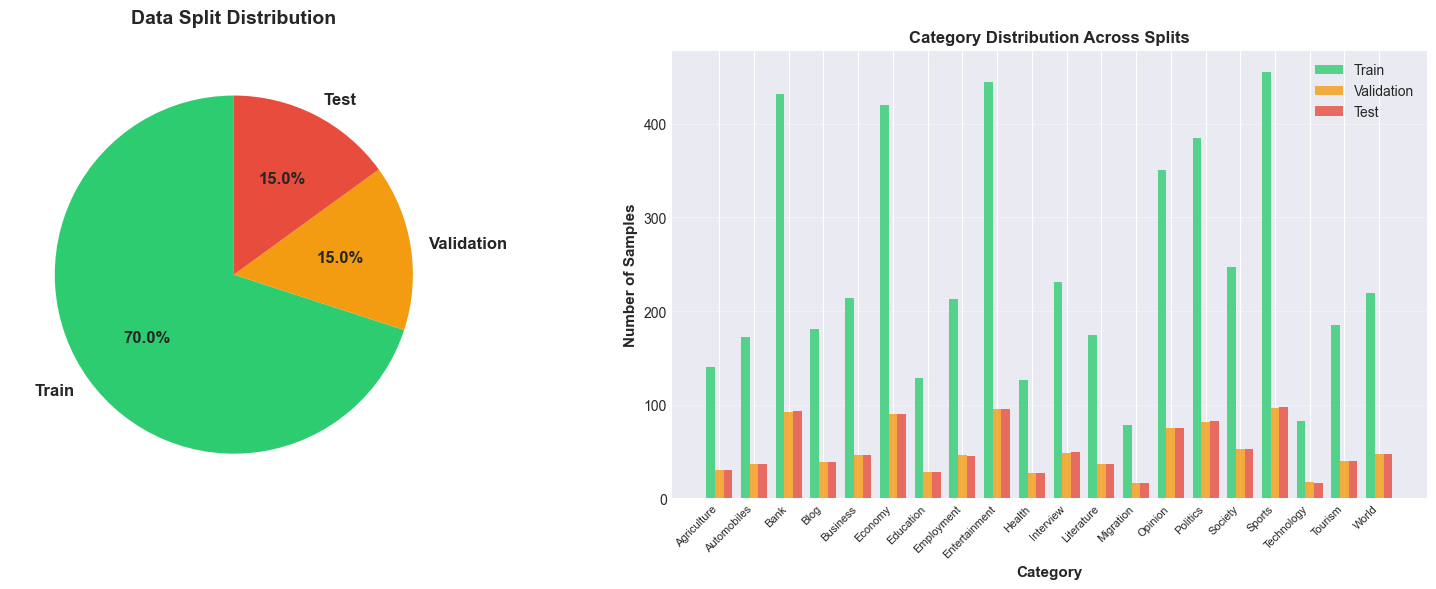

✓ Chart saved to: results/visualizations/data_splits.png


In [8]:
# Visualize split distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart of splits
split_sizes = [len(train_df), len(val_df), len(test_df)]
split_labels = ['Train', 'Validation', 'Test']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].pie(split_sizes, labels=split_labels, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Data Split Distribution', fontsize=14, fontweight='bold', pad=20)

# Bar chart showing category distribution in each split
category_order = sorted(df_cleaned['category'].unique())
train_counts = [len(train_df[train_df['category'] == cat]) for cat in category_order]
val_counts = [len(val_df[val_df['category'] == cat]) for cat in category_order]
test_counts = [len(test_df[test_df['category'] == cat]) for cat in category_order]

x = np.arange(len(category_order))
width = 0.25

axes[1].bar(x - width, train_counts, width, label='Train', color='#2ecc71', alpha=0.8)
axes[1].bar(x, val_counts, width, label='Validation', color='#f39c12', alpha=0.8)
axes[1].bar(x + width, test_counts, width, label='Test', color='#e74c3c', alpha=0.8)

axes[1].set_xlabel('Category', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Samples', fontsize=11, fontweight='bold')
axes[1].set_title('Category Distribution Across Splits', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(category_order, rotation=45, ha='right', fontsize=8)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'results' / 'visualizations' / 'data_splits.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to: results/visualizations/data_splits.png")


In [9]:
# Display detailed category distribution in splits
print("\nCategory Distribution in Splits:")
print("=" * 80)
print(f"{'Category':<20} {'Train':<10} {'Val':<10} {'Test':<10} {'Total':<10}")
print("-" * 80)

for category in sorted(df_cleaned['category'].unique()):
    train_count = len(train_df[train_df['category'] == category])
    val_count = len(val_df[val_df['category'] == category])
    test_count = len(test_df[test_df['category'] == category])
    total = train_count + val_count + test_count
    print(f"{category:<20} {train_count:<10} {val_count:<10} {test_count:<10} {total:<10}")

# Verify stratified sampling
print("\nStratified Sampling Verification:")
print("=" * 80)
for category in sorted(df_cleaned['category'].unique()):
    original_pct = (len(df_cleaned[df_cleaned['category'] == category]) / len(df_cleaned)) * 100
    train_pct = (len(train_df[train_df['category'] == category]) / len(train_df)) * 100
    val_pct = (len(val_df[val_df['category'] == category]) / len(val_df)) * 100
    test_pct = (len(test_df[test_df['category'] == category]) / len(test_df)) * 100
    
    print(f"{category:<20}: Original={original_pct:5.2f}% | Train={train_pct:5.2f}% | Val={val_pct:5.2f}% | Test={test_pct:5.2f}%")



Category Distribution in Splits:
Category             Train      Val        Test       Total     
--------------------------------------------------------------------------------
Agriculture          140        30         30         200       
Automobiles          172        37         37         246       
Bank                 432        92         93         617       
Blog                 181        39         39         259       
Business             214        46         46         306       
Economy              420        90         90         600       
Education            129        28         28         185       
Employment           213        46         45         304       
Entertainment        444        95         95         634       
Health               126        27         27         180       
Interview            231        49         50         330       
Literature           174        37         37         248       
Migration            78         17      

## 5. Compute Class Weights


In [10]:
# Compute class weights for imbalanced dataset
print("Computing class weights...")
print("=" * 80)

class_weights, class_weight_dict = compute_class_weights(
    train_df['category_id'].values,
    method='balanced'
)

print(f"\n✓ Class weights computed!")
print(f"Number of classes: {len(class_weight_dict)}")
print(f"Weight range: {min(class_weight_dict.values()):.4f} - {max(class_weight_dict.values()):.4f}")


2026-01-04 21:54:06,964 - INFO - Class weights computed:
2026-01-04 21:54:06,966 - INFO - ----------------------------------------
2026-01-04 21:54:06,966 - INFO - Class      Weight    
2026-01-04 21:54:06,967 - INFO - ----------------------------------------
2026-01-04 21:54:06,968 - INFO - 0          1.7421    
2026-01-04 21:54:06,969 - INFO - 1          1.4180    
2026-01-04 21:54:06,971 - INFO - 2          0.5646    
2026-01-04 21:54:06,972 - INFO - 3          1.3475    
2026-01-04 21:54:06,974 - INFO - 4          1.1397    
2026-01-04 21:54:06,975 - INFO - 5          0.5807    
2026-01-04 21:54:06,975 - INFO - 6          1.8907    
2026-01-04 21:54:06,976 - INFO - 7          1.1451    
2026-01-04 21:54:06,976 - INFO - 8          0.5493    
2026-01-04 21:54:06,977 - INFO - 9          1.9357    
2026-01-04 21:54:06,978 - INFO - 10         1.0558    
2026-01-04 21:54:06,978 - INFO - 11         1.4017    
2026-01-04 21:54:06,980 - INFO - 12         3.1269    
2026-01-04 21:54:06,981 -

Computing class weights...

✓ Class weights computed!
Number of classes: 20
Weight range: 0.5360 - 3.1269


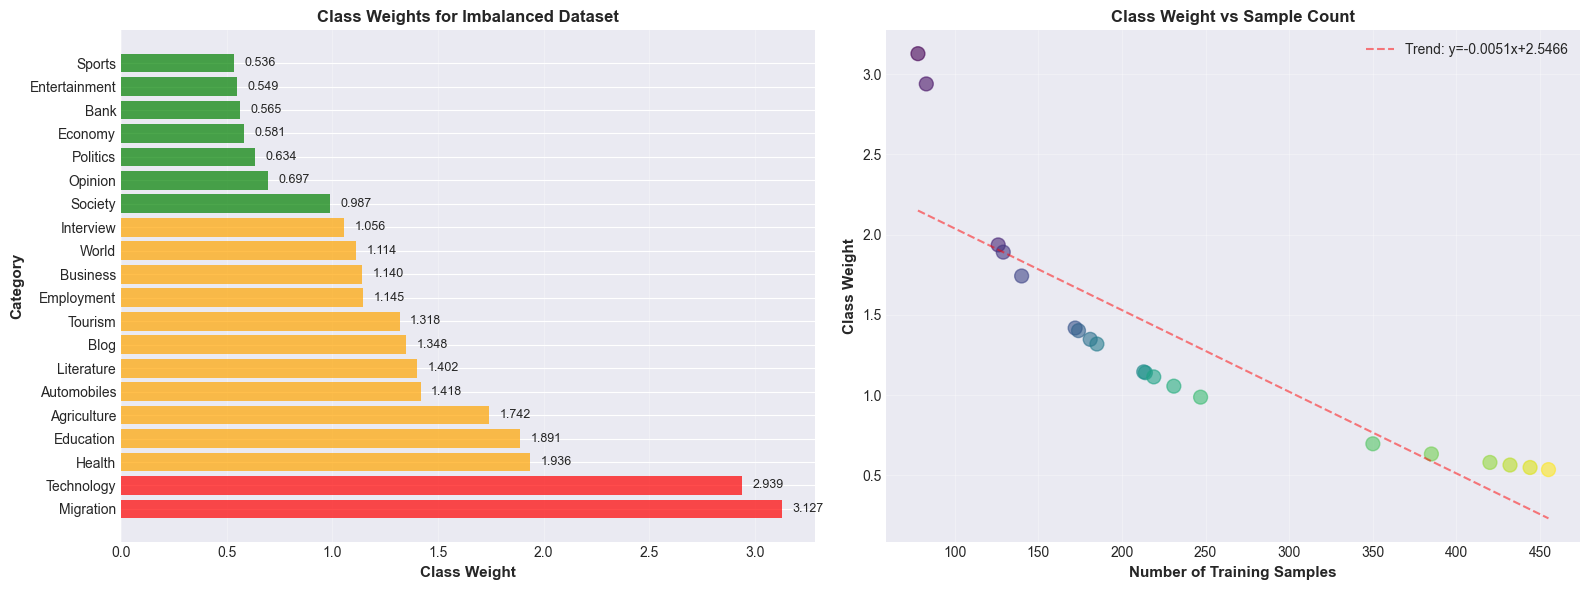

✓ Chart saved to: results/visualizations/class_weights.png


In [11]:
# Visualize class weights
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get category names for weights
category_weights = {id_to_label[cat_id]: weight for cat_id, weight in class_weight_dict.items()}
sorted_weights = dict(sorted(category_weights.items(), key=lambda x: x[1], reverse=True))

# Bar chart of class weights
categories = list(sorted_weights.keys())
weights = list(sorted_weights.values())
colors_weight = ['red' if w > 2.0 else 'orange' if w > 1.0 else 'green' for w in weights]

axes[0].barh(range(len(categories)), weights, color=colors_weight, alpha=0.7)
axes[0].set_yticks(range(len(categories)))
axes[0].set_yticklabels(categories)
axes[0].set_xlabel('Class Weight', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Category', fontsize=11, fontweight='bold')
axes[0].set_title('Class Weights for Imbalanced Dataset', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, (cat, weight) in enumerate(sorted_weights.items()):
    axes[0].text(weight + 0.05, i, f'{weight:.3f}', va='center', fontsize=9)

# Relationship between sample count and weight
category_counts_train = train_df['category'].value_counts()
weight_vs_count = [(category_counts_train[cat], weight) for cat, weight in sorted_weights.items()]
counts, weights_list = zip(*weight_vs_count)

axes[1].scatter(counts, weights_list, s=100, alpha=0.6, c=range(len(counts)), cmap='viridis')
axes[1].set_xlabel('Number of Training Samples', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Class Weight', fontsize=11, fontweight='bold')
axes[1].set_title('Class Weight vs Sample Count', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add trend line
z = np.polyfit(counts, weights_list, 1)
p = np.poly1d(z)
axes[1].plot(counts, p(counts), "r--", alpha=0.5, label=f'Trend: y={z[0]:.4f}x+{z[1]:.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(project_root / 'results' / 'visualizations' / 'class_weights.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved to: results/visualizations/class_weights.png")


In [12]:
# Display class weights table
print("\nClass Weights Table:")
print("=" * 80)
print(f"{'Category':<20} {'Train Samples':<15} {'Class Weight':<15}")
print("-" * 80)

for category in sorted(category_weights.keys()):
    train_count = len(train_df[train_df['category'] == category])
    weight = category_weights[category]
    print(f"{category:<20} {train_count:<15} {weight:<15.4f}")



Class Weights Table:
Category             Train Samples   Class Weight   
--------------------------------------------------------------------------------
Agriculture          140             1.7421         
Automobiles          172             1.4180         
Bank                 432             0.5646         
Blog                 181             1.3475         
Business             214             1.1397         
Economy              420             0.5807         
Education            129             1.8907         
Employment           213             1.1451         
Entertainment        444             0.5493         
Health               126             1.9357         
Interview            231             1.0558         
Literature           174             1.4017         
Migration            78              3.1269         
Opinion              350             0.6969         
Politics             385             0.6335         
Society              247             0.9874      

## 6. Save Processed Data


In [13]:
# Save data splits
print("Saving data splits...")
splits_dir = project_root / 'data' / 'splits'

# Handle case where path exists as a file (Windows issue)
if splits_dir.exists() and splits_dir.is_file():
    splits_dir.unlink()
splits_dir.mkdir(parents=True, exist_ok=True)

save_splits(train_df, val_df, test_df, splits_dir)

print(f"\n✓ Data splits saved to: {splits_dir}")
print(f"  - train.csv: {len(train_df):,} samples")
print(f"  - val.csv: {len(val_df):,} samples")
print(f"  - test.csv: {len(test_df):,} samples")


Saving data splits...


2026-01-04 21:54:09,250 - INFO - Saved train split: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\data\splits\train.csv (4878 samples)
2026-01-04 21:54:09,251 - INFO - Saved validation split: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\data\splits\val.csv (1045 samples)
2026-01-04 21:54:09,252 - INFO - Saved test split: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\data\splits\test.csv (1046 samples)



✓ Data splits saved to: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\data\splits
  - train.csv: 4,878 samples
  - val.csv: 1,045 samples
  - test.csv: 1,046 samples


In [14]:
# Save class weights
weights_path = splits_dir / 'class_weights.json'
with open(weights_path, 'w', encoding='utf-8') as f:
    json.dump(class_weight_dict, f, indent=2, ensure_ascii=False)

print(f"✓ Class weights saved to: {weights_path}")

# Display saved class weights
print("\nSaved class weights (first 5):")
with open(weights_path, 'r', encoding='utf-8') as f:
    saved_weights = json.load(f)
    for i, (cls_id, weight) in enumerate(sorted(saved_weights.items(), key=lambda x: int(x[0]))):
        if i < 5:
            print(f"  Class {cls_id} ({id_to_label[int(cls_id)]}): {weight:.4f}")


✓ Class weights saved to: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\data\splits\class_weights.json

Saved class weights (first 5):
  Class 0 (Agriculture): 1.7421
  Class 1 (Automobiles): 1.4180
  Class 2 (Bank): 0.5646
  Class 3 (Blog): 1.3475
  Class 4 (Business): 1.1397


## 7. Preprocessing Summary


In [15]:
# Generate comprehensive preprocessing summary
print("=" * 80)
print("DATA PREPROCESSING SUMMARY")
print("=" * 80)

print(f"\n1. Dataset Information:")
print(f"   - Total documents: {len(df):,}")
print(f"   - After cleaning: {len(df_cleaned):,}")
print(f"   - Removed empty texts: {len(df) - len(df_cleaned)}")
print(f"   - Number of categories: {len(label_to_id)}")

print(f"\n2. Data Splits:")
print(f"   - Training set: {len(train_df):,} samples ({len(train_df)/len(df_cleaned)*100:.1f}%)")
print(f"   - Validation set: {len(val_df):,} samples ({len(val_df)/len(df_cleaned)*100:.1f}%)")
print(f"   - Test set: {len(test_df):,} samples ({len(test_df)/len(df_cleaned)*100:.1f}%)")
print(f"   - Stratified sampling: ✓ Yes")

print(f"\n3. Tokenizer:")
print(f"   - Model: {tokenizer_name}")
print(f"   - Vocabulary size: {tokenizer.vocab_size:,}")
print(f"   - Max sequence length: 512 tokens")

print(f"\n4. Class Weights:")
print(f"   - Number of classes: {len(class_weight_dict)}")
print(f"   - Weight range: {min(class_weight_dict.values()):.4f} - {max(class_weight_dict.values()):.4f}")
print(f"   - Average weight: {np.mean(list(class_weight_dict.values())):.4f}")

print(f"\n5. Saved Files:")
print(f"   - Train split: data/splits/train.csv")
print(f"   - Validation split: data/splits/val.csv")
print(f"   - Test split: data/splits/test.csv")
print(f"   - Class weights: data/splits/class_weights.json")

print(f"\n6. Visualizations Generated:")
print(f"   - Data splits: results/visualizations/data_splits.png")
print(f"   - Class weights: results/visualizations/class_weights.png")

print("\n" + "=" * 80)
print("✓ Preprocessing pipeline complete!")
print("=" * 80)
print("\nNext steps:")
print("  1. Review the data splits and class weights")
print("  2. Proceed to model training (03_model_training.ipynb)")
print("  3. Use class weights in loss function to handle imbalance")


DATA PREPROCESSING SUMMARY

1. Dataset Information:
   - Total documents: 6,972
   - After cleaning: 6,969
   - Removed empty texts: 3
   - Number of categories: 20

2. Data Splits:
   - Training set: 4,878 samples (70.0%)
   - Validation set: 1,045 samples (15.0%)
   - Test set: 1,046 samples (15.0%)
   - Stratified sampling: ✓ Yes

3. Tokenizer:
   - Model: xlm-roberta-base
   - Vocabulary size: 250,002
   - Max sequence length: 512 tokens

4. Class Weights:
   - Number of classes: 20
   - Weight range: 0.5360 - 3.1269
   - Average weight: 1.3061

5. Saved Files:
   - Train split: data/splits/train.csv
   - Validation split: data/splits/val.csv
   - Test split: data/splits/test.csv
   - Class weights: data/splits/class_weights.json

6. Visualizations Generated:
   - Data splits: results/visualizations/data_splits.png
   - Class weights: results/visualizations/class_weights.png

✓ Preprocessing pipeline complete!

Next steps:
  1. Review the data splits and class weights
  2. Proceed 

In [ ]:
# Save preprocessing summary to JSON
preprocessing_summary = {
    'dataset_info': {
        'total_documents': int(len(df)),
        'after_cleaning': int(len(df_cleaned)),
        'removed_empty': int(len(df) - len(df_cleaned)),
        'num_categories': int(len(label_to_id))
    },
    'splits': {
        'train': {
            'count': int(len(train_df)),
            'percentage': float(len(train_df) / len(df_cleaned) * 100)
        },
        'validation': {
            'count': int(len(val_df)),
            'percentage': float(len(val_df) / len(df_cleaned) * 100)
        },
        'test': {
            'count': int(len(test_df)),
            'percentage': float(len(test_df) / len(df_cleaned) * 100)
        }
    },
    'tokenizer': {
        'model': tokenizer_name,
        'vocab_size': int(tokenizer.vocab_size),
        'max_length': 512
    },
    'class_weights': {
        'num_classes': int(len(class_weight_dict)),
        'min_weight': float(min(class_weight_dict.values())),
        'max_weight': float(max(class_weight_dict.values())),
        'avg_weight': float(np.mean(list(class_weight_dict.values())))
    }
}

summary_path = project_root / 'results' / 'metrics' / 'preprocessing_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(preprocessing_summary, f, indent=2, ensure_ascii=False)

print(f"✓ Preprocessing summary saved to: {summary_path}")


✓ Preprocessing summary saved to: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\results\metrics\preprocessing_summary.json


: 